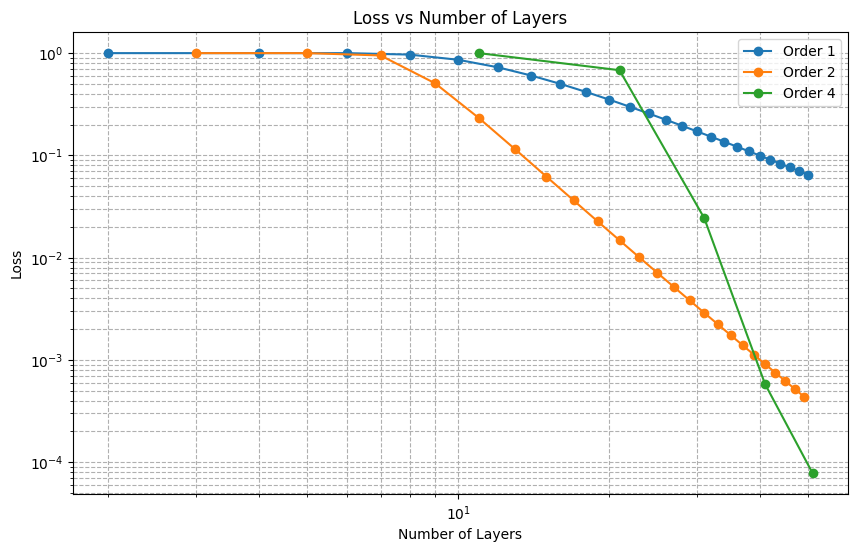

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the CSV file
df = pd.read_csv('trotter_comparison_results_50_ising_hw_friendly.csv')
# df2 = pd.read_csv('trotter_comparison_results_10_hw_friendly_trotter.csv')

# Calculate number of layers based on the order and reps
def calculate_layers(row):
    order = row['order']
    reps = row['reps']
    # method
    if order == 1:
        return 2 * reps
    elif order == 2:
        return 2 * reps + 1
    elif order == 4:
        return 10 * reps + 1
    return None

df['layers'] = df.apply(calculate_layers, axis=1)
# df2['layers'] = df2.apply(calculate_layers, axis=1)

# Plotting
plt.figure(figsize=(10, 6))

for order in [1, 2, 4]:
    subset = df[df['order'] == order].sort_values('layers')
    # subset2 = df2[df2['order'] == order].sort_values('layers')
    plt.plot(subset['layers'], subset['hst_loss'], marker='o', label=f'Order {order}')
    # plt.plot(subset2['layers'], subset2['hst_loss'], marker='o', label=f'Order {order}')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Number of Layers')
plt.ylabel('Loss')
plt.title('Loss vs Number of Layers')
plt.legend()
plt.grid(True, which='both', linestyle='--')
plt.show()